# Implementation of Poisson equation for a compact, spherically symmetric source

Poisson's equations for spherically symmetric sources is given by
\begin{eqnarray}
   \psi''(r) + \frac{2}{r} \psi'(r) = - 4\pi \rho(r),\\
   \psi'(0) = 0,\\
   \lim_{r\to\infty} r \psi = {\rm const}
\end{eqnarray}

As a test case, we solve
\begin{eqnarray}
   \psi''(r) + \frac{2}{r} \psi'(r) =  -\frac{4}{\sqrt{\pi}} e^{-r^2},\\
   \psi'(0) = 0,\\
   \lim_{r\to\infty} r \psi = {\rm const},
\end{eqnarray}
which has the solution $\psi(r) = \frac{{\rm erf}(r)}{r}$.

To avoid the singularity at $r=0$, we construct a grid where the origin lies halfway between two grid points. Specifically, $r_{0} = -h/2$ and $r_1 = h/2$.  The boundary condition at $r=0$ (which is a Neumann BC) is implemented by setting $\psi_0 = \psi_1$. The outer boudary condition is implemented as
$\psi_{-1} = \psi_{-2} \frac{r_{-2}}{r_{-1}}$, 
where the index `-1` refers to the last element on the grid.
The index `-2` refers to the second-to-last index. This boundary is equivalent to the Robin boundary condition $\psi + r \psi' = 0$.





In [1]:
import logging
import numpy as np
from matplotlib import pyplot as plt
import multigrid_numba as multi
from scipy.special import erf
from timeit import default_timer
from numba import njit

In [2]:
@njit
def DirichletDirichlet(_grid, y, level):
    y[0] = 0
    y[-1] = 0 if level > 0 else 2


@njit
def NeumannDirichlet(_grid, y, level):
    y[0] = y[1]
    y[-1] = 0 if level > 0 else 2


@njit
def NeumannRobin(grid, y, _level):
    y[0] = y[1]
    y[-1] = y[-2] * grid[-2] / grid[-1]

In [3]:
def setup_grid(num_cells, r_end):
    h = r_end / num_cells
    r_start = -h / 2
    r_end = r_end - h / 2

    grid = np.linspace(r_start, r_end, num_cells + 1)

    d2 = np.ones(num_cells + 1)
    d1 = 2 * np.ones(num_cells + 1) / grid
    d0 = np.zeros(num_cells + 1)
    src = -4 * np.pi * (np.exp(-(grid**2)) / np.pi**1.5)
    mg = multi.Multigrid(
        num_cells,
        grid=grid,
        d0_coeff=d0,
        d1_coeff=d1,
        d2_coeff=d2,
        src=src,
        omega_sor=1.5,
        boundary=NeumannRobin,
        min_cells=20,
        tol=2.0e-9,
        red_black_decouple=False,
    )

    mg.logger.handlers[0].setLevel(logging.DEBUG)
    mg.logger.setLevel(logging.DEBUG)
    return mg, grid

In [4]:
mg, grid = setup_grid(1024, 20.0)
start = default_timer()
mg.solve_to_tolerance(smoothing_iters=1000, max_vcycle_iters=100)
end = default_timer()
print(f"solve took {end - start} seconds")
print(f"solve required {mg._iterations_required} iterations on parent grid")

err=np.float64(2.2565431232070825) at it=0
Starting Vcycle
 restrict at 1024
 *  restrict at 512
 *  *  restrict at 256
 *  *  *  restrict at 128
 *  *  *  *  restrict at 64
 *  *  *  *  *  prolongate at 32
 *  *  *  *  prolongate at 64
 *  *  *  prolongate at 128
 *  *  prolongate at 256
 *  prolongate at 512
err=6.16474120951338e-06 at it=1
Starting Vcycle
 restrict at 1024
 *  restrict at 512
 *  *  restrict at 256
 *  *  *  restrict at 128
 *  *  *  *  restrict at 64
 *  *  *  *  *  prolongate at 32
 *  *  *  *  prolongate at 64
 *  *  *  prolongate at 128
 *  *  prolongate at 256
 *  prolongate at 512
err=2.4765757444811243e-08 at it=2
Starting Vcycle
 restrict at 1024
 *  restrict at 512
 *  *  restrict at 256
 *  *  *  restrict at 128
 *  *  *  *  restrict at 64
 *  *  *  *  *  prolongate at 32
 *  *  *  *  prolongate at 64
 *  *  *  prolongate at 128
 *  *  prolongate at 256
 *  prolongate at 512
err=2.335279320180711e-10 at it=3
solution achieved with tol=2.335279320180711e-10

solve took 0.795304175990168 seconds
solve required 6000 iterations on parent grid


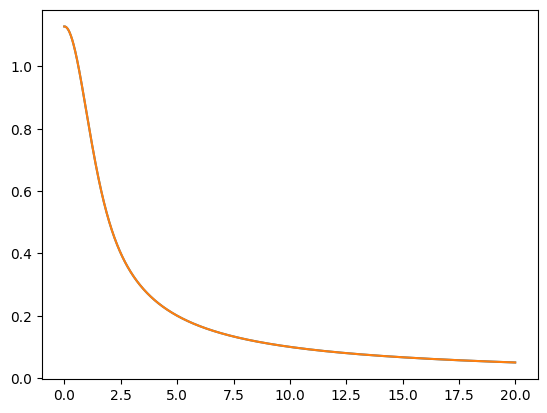

In [5]:
plt.plot(grid, mg.solution)
plt.plot(grid, erf(grid) / grid)

7.171801273586631e-05


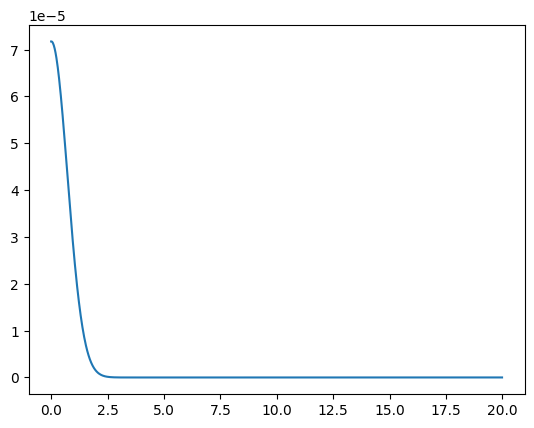

In [6]:
plt.plot(grid, mg.solution - erf(grid) / grid)
print(np.linalg.norm(mg.solution - erf(grid) / grid, np.inf))

In [7]:
mg, grid = setup_grid(1024, 20.0)

In [8]:
def iterate_to_solution(mg, n_iters=100, tol=2.0e-9):
    mg.calculate_defect()
    err = np.linalg.norm(mg.defect, np.inf)
    while err > tol:
        mg.gauss_seidel_smoothing(n_iters=n_iters)
        mg.calculate_defect()
        err = np.linalg.norm(mg.defect, np.inf)
        print(err)

In [9]:
start = default_timer()
iterate_to_solution(mg, n_iters=50000, tol=1.0e-9)
end = default_timer()
print(f"solve took {end - start} seconds")
print(f"solve required {mg._iterations_required} iterations on parent grid")

0.0026550352813483613
0.0012538301614384295
0.0008558837541183806
0.0006004905009451278
0.00042200606970954624
0.00029660210668058795
0.00020846459854340083
0.00014651785677211038
0.00010297902350231425
7.237805941073816e-05
5.087041252238578e-05
3.575389346055502e-05
2.5129372513976733e-05
1.7662004827556643e-05
1.2413614456807665e-05
8.72482501801386e-06
6.1321789672774685e-06
4.309973008265189e-06
3.0292298451861654e-06
2.1290728162703942e-06
1.4964102570402815e-06
1.05173865261321e-06
7.392089154123482e-07
5.1955299351647e-07
3.651629940648604e-07
2.5664645164624744e-07
1.803757894158764e-07
1.267828317885744e-07
8.91061771035595e-08
6.26310043827516e-08
4.403482112280699e-08
3.0940425777004066e-08
2.1748272072130703e-08
1.527208759455334e-08
1.0758665514032373e-08
7.540946089790168e-09
5.333711694532894e-09
3.7201952629573043e-09
2.6200703828749283e-09
1.8622063890916252e-09
1.322039810958131e-09
8.901386294724034e-10
solve took 14.515203711023787 seconds
solve required 2100000 it